In [22]:
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
train = pd.read_csv("train_final.csv")
test = pd.read_csv("test_final.csv")
ids = test["row_id"]

In [24]:
train

,row_id,date,store_id,city,region,product_id,product_name,category,price,loyalty_day,is_holiday,holiday_name,demand
0,725,2025-05-10,CM-BAC-01,Bacău,Moldova,P0001,Apă plată 2L,Beverages,4.08,0,0,NaN,7
1,1451,2025-05-10,CM-BAC-01,Bacău,Moldova,P0002,Apă minerală carbogazoasă 1.5L,Beverages,8.68,0,0,NaN,8
2,2177,2025-05-10,CM-BAC-01,Bacău,Moldova,P0003,Cola 2L,Beverages,9.73,0,0,NaN,2
3,2903,2025-05-10,CM-BAC-01,Bacău,Moldova,P0004,Suc natural portocale 1L,Beverages,8.60,0,0,NaN,0
4,3629,2025-05-10,CM-BAC-01,Bacău,Moldova,P0005,Bere lager 0.5L,Beverages,4.26,0,0,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
421075,417450,2023-05-15,CM-TIM-01,Timișoara,Banat,P0054,Mălai 1kg,Pantry,NaN,1,0,NaN,0
421076,418176,2023-05-15,CM-TIM-01,Timișoara,Banat,P0055,Joc puzzle mini,Toys & Games,NaN,1,0,NaN,0
421077,418902,2023-05-15,CM-TIM-01,Timișoara,Banat,P0056,Bandă elastică fitness,Sports & Hobbies,NaN,1,0,NaN,0
421078,419628,2023-05-15,CM-TIM-01,Timișoara,Banat,P0057,Lingură silicon 30cm,Home & Kitchen,NaN,1,0,NaN,0


In [ ]:
def prep(train, test):
    df = pd.concat([train, test])
    df["date"] = pd.to_datetime(df["date"])

    df["day"] = df["date"].dt.day
    df["month"] = df["date"].dt.month
    df["year"] = df["date"].dt.year
    df["dayofweek"] = df["date"].dt.dayofweek
    df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)

    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    df = df.drop(columns=["date", "row_id"])
    df = pd.get_dummies(df)
    df["days_since_2019"] = 

    train = df[:len(train)]
    test = df[len(train):]

    return train, test


In [26]:
train, test = prep(train, test)

In [27]:
X_train = train.drop(columns="demand")
y_train = train["demand"]
X_test = test

In [28]:
train

,price,loyalty_day,is_holiday,demand,day,month,year,dayofweek,weekofyear,is_weekend,...,holiday_name_Sf. Andrei,holiday_name_Sf. Maria,holiday_name_Sf. Nicolae,holiday_name_Sf. Valentin,holiday_name_Unirea Principatelor,holiday_name_Vinerea Mare,holiday_name_Ziua Copilului,holiday_name_Ziua Femeii,holiday_name_Ziua Muncii,holiday_name_Ziua Națională
0,4.08,0,0,7.0,10,5,2025,5,19,1,...,False,False,False,False,False,False,False,False,False,False
1,8.68,0,0,8.0,10,5,2025,5,19,1,...,False,False,False,False,False,False,False,False,False,False
2,9.73,0,0,2.0,10,5,2025,5,19,1,...,False,False,False,False,False,False,False,False,False,False
3,8.60,0,0,0.0,10,5,2025,5,19,1,...,False,False,False,False,False,False,False,False,False,False
4,4.26,0,0,0.0,10,5,2025,5,19,1,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421075,NaN,1,0,0.0,15,5,2023,0,20,0,...,False,False,False,False,False,False,False,False,False,False
421076,NaN,1,0,0.0,15,5,2023,0,20,0,...,False,False,False,False,False,False,False,False,False,False
421077,NaN,1,0,0.0,15,5,2023,0,20,0,...,False,False,False,False,False,False,False,False,False,False
421078,NaN,1,0,0.0,15,5,2023,0,20,0,...,False,False,False,False,False,False,False,False,False,False


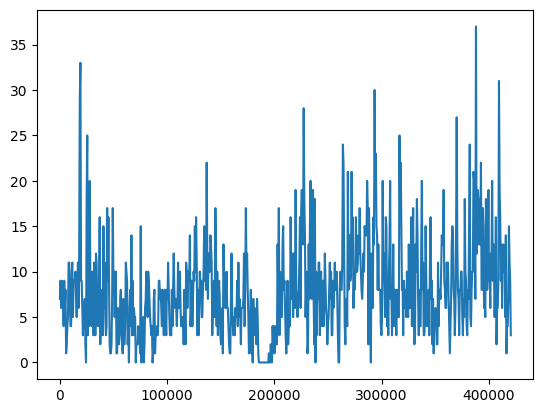

In [29]:
plt.plot(matching_rows["demand"])

In [30]:
from catboost import CatBoostRegressor
from sklearn.svm import SVR

model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

In [32]:
model.fit(X_train, y_train)

0:	learn: 2.7421307	total: 72.4ms	remaining: 3m 37s
100:	learn: 2.2092094	total: 1.39s	remaining: 39.9s
200:	learn: 2.1254894	total: 2.65s	remaining: 36.8s
300:	learn: 2.0768472	total: 3.88s	remaining: 34.8s
400:	learn: 2.0379474	total: 5.16s	remaining: 33.5s
500:	learn: 2.0114581	total: 6.37s	remaining: 31.8s
600:	learn: 1.9895945	total: 7.58s	remaining: 30.3s
700:	learn: 1.9705697	total: 8.79s	remaining: 28.8s
800:	learn: 1.9559947	total: 10s	remaining: 27.5s
900:	learn: 1.9440609	total: 11.3s	remaining: 26.2s
1000:	learn: 1.9312359	total: 12.5s	remaining: 24.9s
1100:	learn: 1.9209878	total: 13.7s	remaining: 23.6s
1200:	learn: 1.9112206	total: 14.9s	remaining: 22.4s
1300:	learn: 1.9028124	total: 16.2s	remaining: 21.2s
1400:	learn: 1.8936164	total: 17.5s	remaining: 19.9s
1500:	learn: 1.8847353	total: 18.7s	remaining: 18.7s
1600:	learn: 1.8762698	total: 19.9s	remaining: 17.4s
1700:	learn: 1.8685459	total: 21.2s	remaining: 16.2s
1800:	learn: 1.8618686	total: 22.4s	remaining: 14.9s
1900:

CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=3000, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

In [33]:
pred = model.predict(X_test)

In [34]:
f = open("ans1.csv", 'w')

f.write("row_id,demand\n")

for i, p in enumerate(pred):
    f.write(str(ids[i]) + "," + str(p) + '\n')
f.close()